In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
# File uploading
data = pd.read_csv(r"C:\Users\mahla\Downloads\netflix.csv", engine='python')

In [20]:
#Data

print(data.head())
print(data.tail())

  Release_Date                    Title  \
0   2021-12-15  Spider-Man: No Way Home   
1   2022-03-01               The Batman   
2   2022-02-25                  No Exit   
3   2021-11-24                  Encanto   
4   2021-12-22           The King's Man   

                                            Overview  Popularity Vote_Count  \
0  Peter Parker is unmasked and no longer able to...    5083.954       8940   
1  In his second year of fighting crime, Batman u...    3827.658       1151   
2  Stranded at a rest stop in the mountains durin...    2618.087        122   
3  The tale of an extraordinary family, the Madri...    2402.201       5076   
4  As a collection of history's worst tyrants and...    1895.511       1793   

  Vote_Average Original_Language                               Genre  \
0          8.3                en  Action, Adventure, Science Fiction   
1          8.1                en            Crime, Mystery, Thriller   
2          6.3                en                  

In [21]:
#Data Shape

data.shape

(9837, 9)

In [22]:
#Data Description

data.describe()

,Popularity
count,9827.000000
mean,40.320570
std,108.874308
min,7.100000
25%,16.127500
50%,21.191000
75%,35.174500
max,5083.954000


In [18]:
#Data overview

data.columns
data.nunique()

Release_Date         5903
Title                9514
Overview             9823
Popularity           8160
Vote_Count           3267
Vote_Average           75
Original_Language      44
Genre                2337
Poster_Url           9826
dtype: int64

In [23]:
#cleaning data
data.isnull().sum()

Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

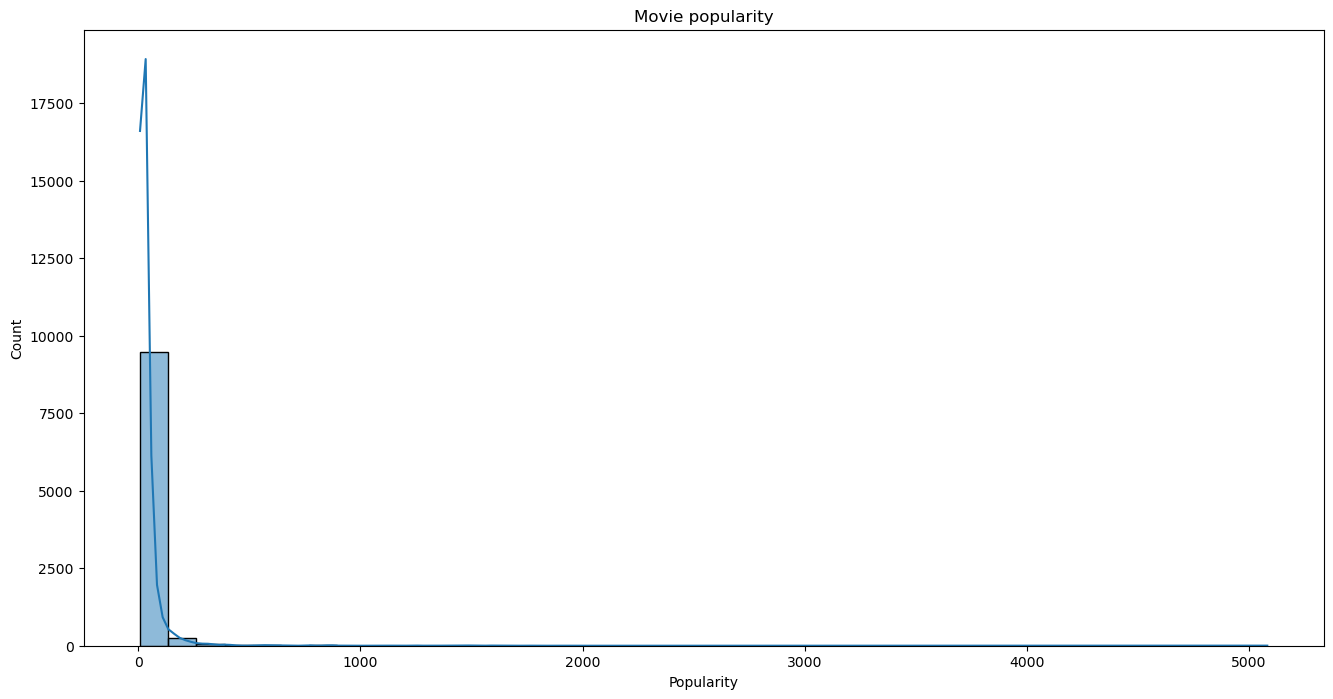

In [24]:
#data visualisation
#1. Popularity
plt.figure(figsize=(16,8))
sns.histplot(data['Popularity'], bins=40, kde=True)
plt.title('Movie popularity')
plt.show()

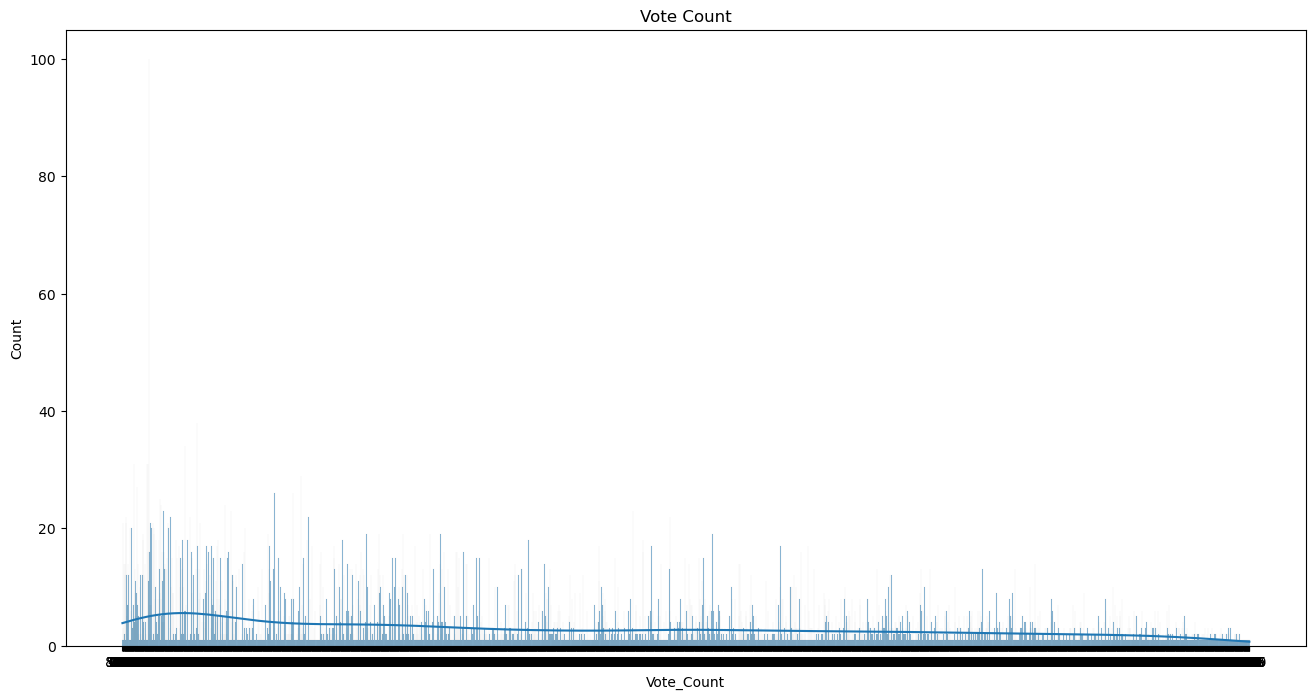

In [25]:
#2. Vote count analysis
plt.figure(figsize=(16,8))
sns.histplot(data['Vote_Count'], bins=40, kde=True)
plt.title('Vote Count')
plt.show()

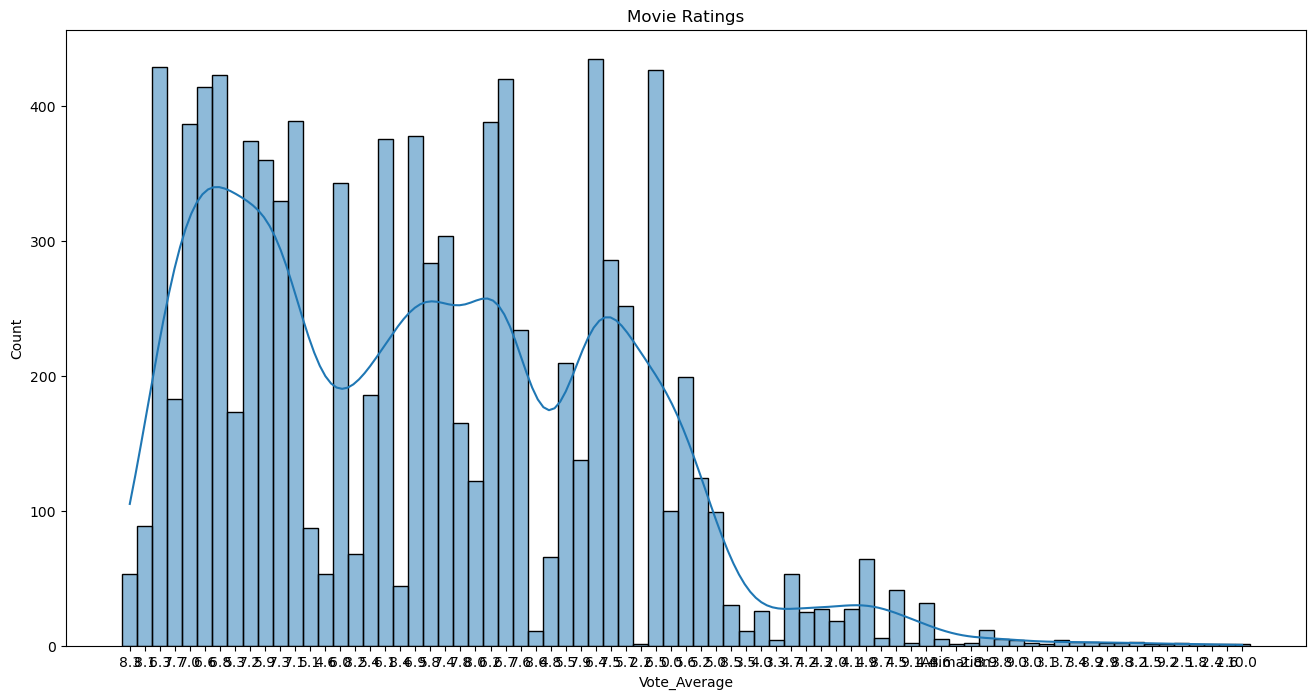

In [26]:
#3 Ratings analysis
plt.figure(figsize=(16,8))
sns.histplot(data['Vote_Average'], bins=20, kde=True)
plt.title('Movie Ratings')
plt.show()

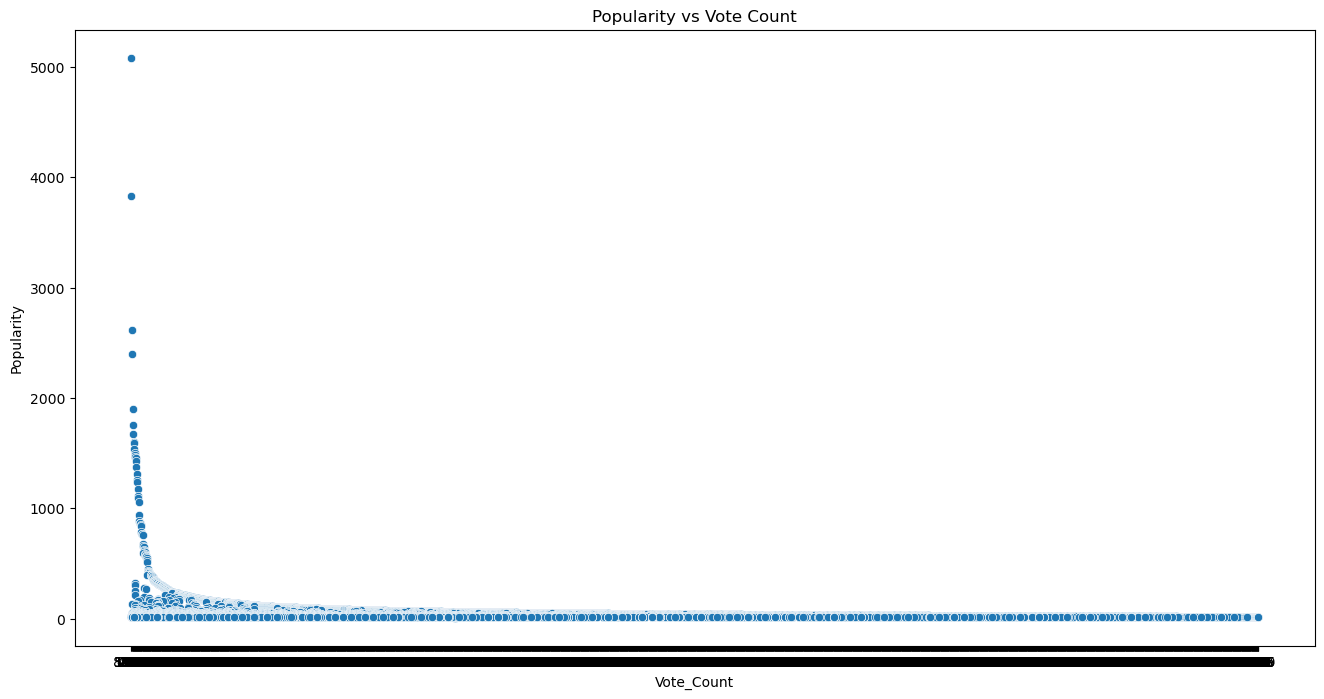

In [32]:
#4. Popoularity vs Vote Count
plt.figure(figsize=(16,8))

sns.scatterplot(
    data=data,
    x='Vote_Count',
    y='Popularity'
)

plt.title('Popularity vs Vote Count')
plt.show()

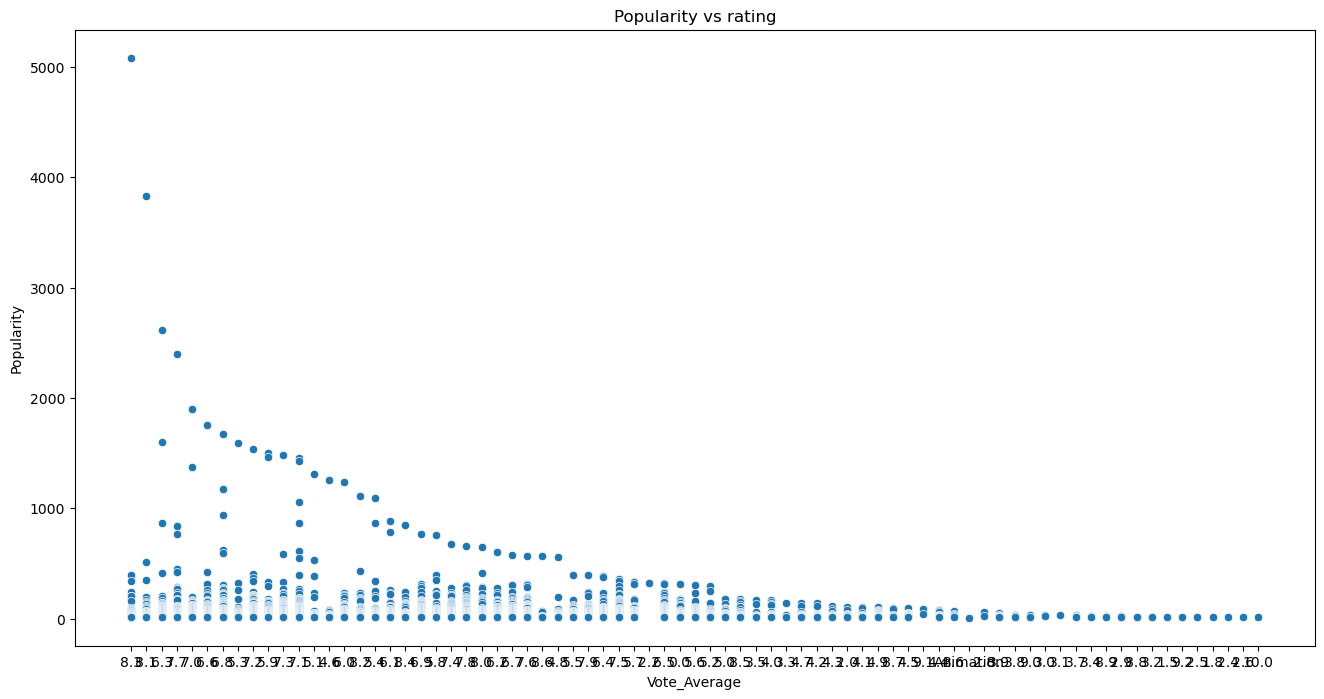

In [33]:
#5. Popularity vs ratings
plt.figure(figsize=(16,8))

sns.scatterplot(
    data=data,
    x='Vote_Average',
    y='Popularity'
)

plt.title('Popularity vs rating')
plt.show()

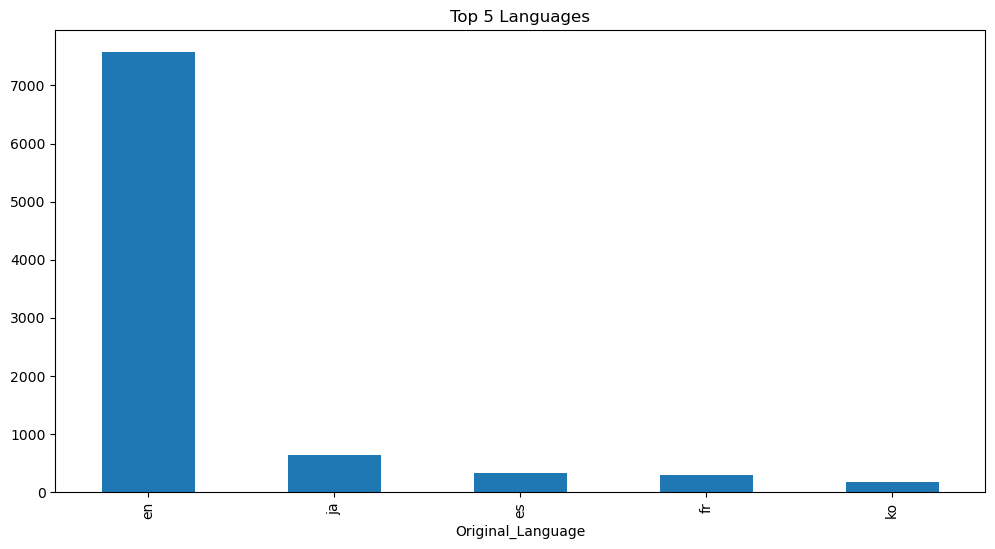

In [29]:
#6. Dominating movie languages
plt.figure(figsize=(12,6))

data['Original_Language']\
.value_counts()\
.head(5)\
.plot(kind='bar')


plt.title('Top 5 Languages')
plt.show()

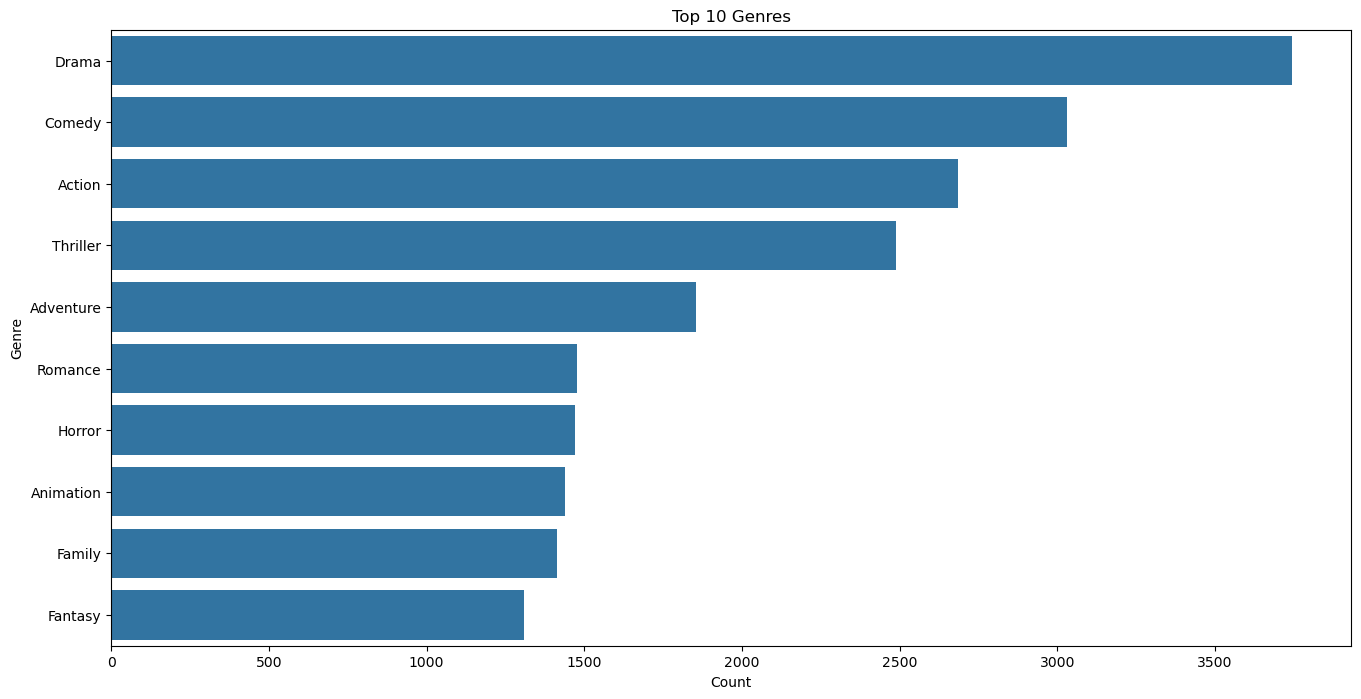

In [30]:
#7. Dominating movie genre
from collections import Counter

genres = data['Genre'].dropna().str.split(', ')

genre_count = Counter()

for g in genres:
    genre_count.update(g)

genre_df = (
    pd.DataFrame(
        genre_count.items(),
        columns=['Genre','Count']
    )
    .sort_values('Count', ascending=False)
)

plt.figure(figsize=(16,8))

sns.barplot(
    data=genre_df.head(10),
    x='Count',
    y='Genre'
)

plt.title('Top 10 Genres')
plt.show()

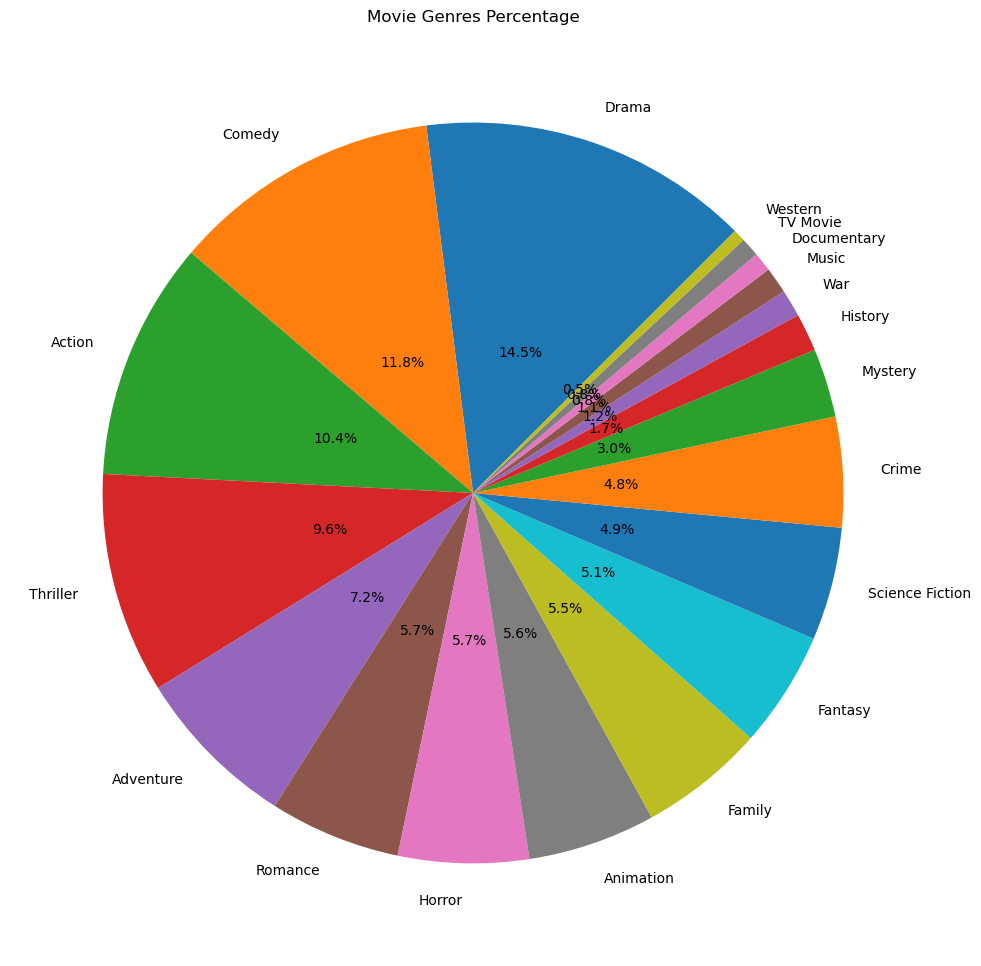

In [31]:
#8. Pie chart genre analysis
plt.figure(figsize=(10, 10))

plt.pie(
    genre_df['Count'],
    labels=genre_df['Genre'],
    autopct='%1.1f%%',
    startangle=45,
    pctdistance=0.4
)

plt.title('Movie Genres Percentage')
plt.tight_layout()
plt.show()